# Análisis Exploratorio de Datos — Anuncios de Coches

**TFG — Ingeniería de Datos | coches.net**

Análisis exploratorio del corpus de ~25.000 anuncios de coches de segunda mano.
Aplica la **misma segmentación de tres niveles** (Utilitario · plus · premium),
las mismas constantes de marcas y los mismos criterios de limpieza y filtrado P2-P98
que el pipeline ML (`ml_coches.ipynb`), garantizando coherencia analítica entre ambos notebooks.

| Sección | Contenido |
|---------|-----------|
| 1 | Segmentación de mercado y carga de datos |
| 2 | Calidad del dataset — nulos y estructura |
| 3 | Análisis univariante |
| 4 | Análisis bivariante y por segmento |
| 5 | Análisis multivariante |
| 6 | Distribución geográfica y ranking de marcas |
| 7 | Análisis de descuento sobre precio original |

> **Convención:** `CSV_PATH = 'anuncios.csv'` junto al notebook en tiempo de ejecución.

In [1]:
import json
import warnings
warnings.filterwarnings("ignore")

import os
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import squarify                        # pip install squarify

# Database
import psycopg2
from sqlalchemy import create_engine

# ── Configuración global ───────────────────────────────────────────────────
RANDOM_SEED = 42
CSV_PATH    = 'anuncios.csv'           # CSV junto al notebook
ANO_ACTUAL  = 2026

os.makedirs('IMG', exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
})

# Paleta de segmentos (coherente con ml_coches.ipynb)
SEG_COLORS = {'Utilitario': '#2196F3', 'plus': '#FF9800', 'premium': '#9C27B0'}
SEG_ORDER  = ['Utilitario', 'plus', 'premium']

print("Librerías cargadas")

# Configuración de conexión
DB_CONFIG = {
    'dbname': 'anuncios',
    'host': 'localhost',
    'port': '5432'
}

DB_USER = 'config/db_config.json'

# Configuración de conexión
DB_CONFIG = {
    'dbname': 'anuncios',
    'host': 'localhost',
    'port': '5432'
}

DB_USER = 'config/db_config.json'

with open(DB_USER, 'r') as f:
    user_config = json.load(f)
    user = user_config['usser']
    password = user_config['password']

# Crear engine de PostgreSQL
engine = create_engine(f"postgresql://{user}:{password}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}")

print("Conexión a la base de datos establecida")


Librerías cargadas
Conexión a la base de datos establecida


In [2]:
# Creamos el CSV y cargamos el DataFrame para su analisis
df = pd.read_sql("SELECT * FROM anuncios", engine)
df.drop(columns='comments').to_csv('anuncios.csv', index=True, encoding='utf-8',)  # Guardar el DataFrame en un archivo CSV
comments = pd.read_sql("SELECT id,comments FROM anuncios", engine)
comments.to_csv('comments.csv', index=True, encoding='utf-8',)  # Guardar el DataFrame de comentarios en un archivo CSV
df.head()

,id,brand,model,price,original_price,year,km,cv,cc,fuel,...,doors,seats,car_type,location,label,comments,url,extendido,created_at,updated_at
0,62479826,SEAT,SEAT Ibiza 1.0 TSI Special Edition,17790.0,23040.0,2025.0,15737.0,115.0,999.0,Gasolina,...,5.0,5.0,Berlina,madrid,Etiqueta C (verde),Ref. 362292\nPrecio: 17.790 EUR\n\nTipo de mot...,https://www.coches.net/seat-ibiza-10-tsi-85kw-...,S,2026-02-08 18:40:29.021480,2026-04-16 13:33:35.129534
1,62595348,BMW,BMW Serie 3 318d Gran Turismo,14900.0,NaN,2019.0,120000.0,150.0,1995.0,Diesel,...,5.0,5.0,Berlina,cadiz,None,BMW 318d Gran Turismo 2019 – 197cv – Muy cuida...,https://www.coches.net/bmw-serie-3-318d-gran-t...,S,2026-03-08 23:19:19.850154,2026-04-16 13:33:32.176463
2,62646888,MERCEDES-BENZ,MERCEDES-BENZ Clase C,6790.0,NaN,1997.0,302000.0,NaN,NaN,Gasolina,...,5.0,NaN,None,desconocida,None,"TRASPASO INCLUIDO, Itv recién pasada, distribu...",https://www.coches.net/mercedes-benz-clase-c-g...,S,2026-03-27 20:19:31.580541,2026-04-16 13:33:34.675345
3,70042922,AUDI,AUDI A4 Allroad Quattro 2.0 TDI DPF,10990.0,42410.0,2011.0,261000.0,170.0,1968.0,Diesel,...,5.0,5.0,Familiar,salamanca,Etiqueta B (amarilla),"Audi A4 allroad Quattro , 2.0TDI 170CV , cambi...",https://www.coches.net/audi-a4-allroad-quattro...,S,2026-04-10 17:52:08.367333,2026-04-16 13:33:32.176463
4,62555907,AUDI,AUDI Q2 S line 30 TDI,29950.0,36120.0,2025.0,23465.0,116.0,1968.0,Diesel,...,5.0,5.0,SUV,murcia,None,HUERTAS MOTOR CONCESIONARIO OFICIAL AUDI en M...,https://www.coches.net/audi-q2-s-line-30-tdi-8...,S,2026-02-19 21:08:58.772675,2026-04-16 13:33:32.176463


## 1. Segmentación de Mercado y Carga de Datos

Se aplica la **misma lógica de tres niveles** que en `ml_coches.ipynb`:

- **premium**: marca de lujo absoluto **O** precio > P97 (umbral dinámico ~57.500 €).
  El criterio OR permite capturar versiones de alta especificación de marcas plus
  (p. ej. un Porsche 911 GT2 RS de 300.000 €) que en precio se comportan como premium.
- **plus**: marca de gama alta con precio ≤ umbral premium. La condición de marca es necesaria.
- **Utilitario**: todo lo que no cumple ninguna de las condiciones anteriores.

In [3]:
# ── Constantes de segmentación — IDÉNTICAS a ml_coches.ipynb ──────────────
MARCAS_premium = {
    "FERRARI", "LAMBORGHINI", "BENTLEY", "ASTON MARTIN",
    "MASERATI", "BUGATTI", "ROLLS-ROYCE", "LOTUS", "MCLAREN",
}
MARCAS_plus = {
    "BMW", "MERCEDES-BENZ", "AUDI", "PORSCHE", "LEXUS", "JAGUAR",
    "LAND-ROVER", "ALFA ROMEO", "VOLVO", "MINI", "TESLA", "DS",
    "ALPINE", "CADILLAC", "CORVETTE",
}

def asignar_segmento(brand, price, umbral_premium):
    """Clasificación jerárquica: premium > plus > Utilitario."""
    b = str(brand).upper().strip() if pd.notna(brand) else ""
    p = price if pd.notna(price) else 0
    if b in MARCAS_premium or p > umbral_premium:
        return "premium"
    if b in MARCAS_plus:
        return "plus"
    return "Utilitario"


In [4]:
# ── Carga del CSV ─────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

# Kilometraje corrupto (valor máximo entero de PostgreSQL): clipeado a 500.000
df['km'] = df['km'].clip(upper=500_000)

# Antigüedad como diferencia al año actual (coherente con ml_coches.ipynb)
df['antiguedad'] = ANO_ACTUAL - df['year']

# ── Segmentación ──────────────────────────────────────────────────────────
umbral_premium = df['price'].quantile(0.97)
print(f"Umbral premium (P97): {umbral_premium:,.0f} €\n")

df['segmento'] = df.apply(
    lambda r: asignar_segmento(r['brand'], r['price'], umbral_premium), axis=1
)

# ── Resumen de segmentación ───────────────────────────────────────────────
resumen = df.groupby('segmento').agg(
    n               = ('id',    'count'),
    precio_mediana  = ('price', 'median'),
    precio_media    = ('price', 'mean'),
    km_mediana      = ('km',    'median'),
).round(0).loc[SEG_ORDER]
print(resumen.to_string())
print(f"\nTotal: {len(df):,} anuncios")
df.describe(include='all').round(2).T


Umbral premium (P97): 57,500 €

                n  precio_mediana  precio_media  km_mediana
segmento                                                   
Utilitario  16339         13200.0       14404.0    101226.0
plus         7952         21990.0       22960.0    120000.0
premium       757         77900.0       99356.0     34534.0

Total: 25,048 anuncios


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,25048.0,NaN,NaN,NaN,12523.5,7230.88,0.0,6261.75,12523.5,18785.25,25047.0
id,25048.0,NaN,NaN,NaN,63190803.99,2458242.51,52202057.0,62382674.75,62525731.5,62617348.25,70326195.0
brand,24181,52,AUDI,2429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,25039,9982,VOLKSWAGEN Golf,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,25038.0,NaN,NaN,NaN,19690.03,21384.21,300.0,8500.0,15972.5,24900.0,850000.0
original_price,16298.0,NaN,NaN,NaN,38160.9,26211.13,6290.0,23722.5,31775.0,43440.0,366525.0
year,25039.0,NaN,NaN,NaN,2016.5,7.18,1981.0,2012.0,2019.0,2022.0,2026.0
km,25033.0,NaN,NaN,NaN,123890.25,92976.23,1.0,52100.0,105000.0,179000.0,500000.0
cv,20607.0,NaN,NaN,NaN,158.65,86.02,8.0,110.0,136.0,178.0,920.0
cc,19957.0,NaN,NaN,NaN,1712.97,620.31,1.0,1360.0,1595.0,1984.0,6750.0


## 2. Calidad del Dataset

Auditoría de valores ausentes y estructura antes de pasar al análisis gráfico.
Las columnas con alto porcentaje de nulos (`original_price`, `label`, `cv`, `cc`, `seats`)
se imputan por mediana en el pipeline ML; aquí se preservan como `NaN`.

In [5]:
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas\n")
print(f"Tipos de datos:\n{df.dtypes.to_string()}\n")

nulos = df.isnull().sum().sort_values(ascending=False)
pct   = (nulos / len(df) * 100).round(1)
tabla_nulos = pd.DataFrame({
    'Nulos': nulos, '% del total': pct,
    'No nulos': len(df) - nulos
}).query('Nulos > 0')
print(tabla_nulos.to_string())
print(f"\nDuplicados exactos: {df.duplicated().sum()}")


Dimensiones: 25,048 filas × 23 columnas

Tipos de datos:
Unnamed: 0          int64
id                  int64
brand              object
model              object
price             float64
original_price    float64
year              float64
km                float64
cv                float64
cc                float64
fuel               object
transmission       object
doors             float64
seats             float64
car_type           object
location           object
label              object
url                object
extendido          object
created_at         object
updated_at         object
antiguedad        float64
segmento           object

                Nulos  % del total  No nulos
label            9818         39.2     15230
original_price   8750         34.9     16298
cc               5091         20.3     19957
seats            4447         17.8     20601
cv               4441         17.7     20607
car_type         4422         17.7     20626
brand             867        

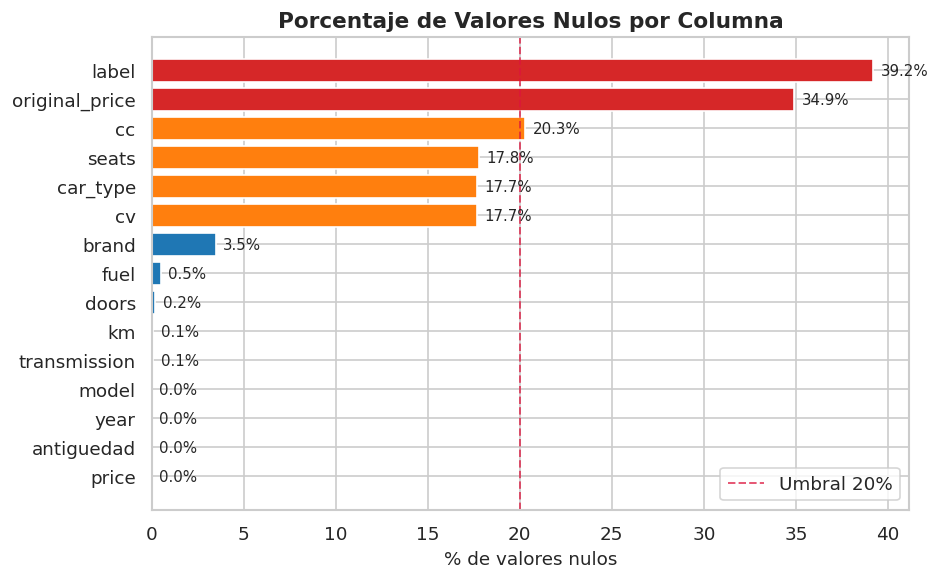

In [6]:
# ── Barplot horizontal de nulos ────────────────────────────────────────────
# Justificación: da contexto de fiabilidad antes de cada gráfico posterior;
# columnas con >20% de nulos requieren cautela en la interpretación.
fig, ax = plt.subplots(figsize=(8, 5))
cols_nulos = tabla_nulos.sort_values('% del total').index.tolist()
vals       = tabla_nulos.loc[cols_nulos, '% del total']
colors     = ['#d62728' if v > 30 else '#ff7f0e' if v > 15 else '#1f77b4'
              for v in vals]
ax.barh(cols_nulos, vals, color=colors, edgecolor='white')
ax.axvline(20, color='crimson', linestyle='--', linewidth=1.2,
           alpha=0.7, label='Umbral 20%')
for i, v in enumerate(vals):
    ax.text(v + 0.4, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de Valores Nulos por Columna')
ax.legend()
plt.tight_layout()
plt.savefig('IMG/nulos_por_columna.png', bbox_inches='tight')
plt.show()


## 3. Análisis Univariante

Distribuciones individuales de las variables clave. El filtrado **P2–P98 se aplica
por separado en cada segmento y cada gráfico**, evitando la eliminación de filas
del dataset mientras se suprime el efecto visual de los outliers.

In [7]:
def p2_p98(serie):
    """Devuelve máscara booleana con el rango P2-P98 de una serie."""
    lo, hi = serie.quantile(0.02), serie.quantile(0.98)
    return (serie >= lo) & (serie <= hi)

def filtrar_seg(seg, col='price'):
    """Filas del segmento con la columna dentro de P2-P98."""
    d = df[df['segmento'] == seg].copy()
    return d[p2_p98(d[col])]


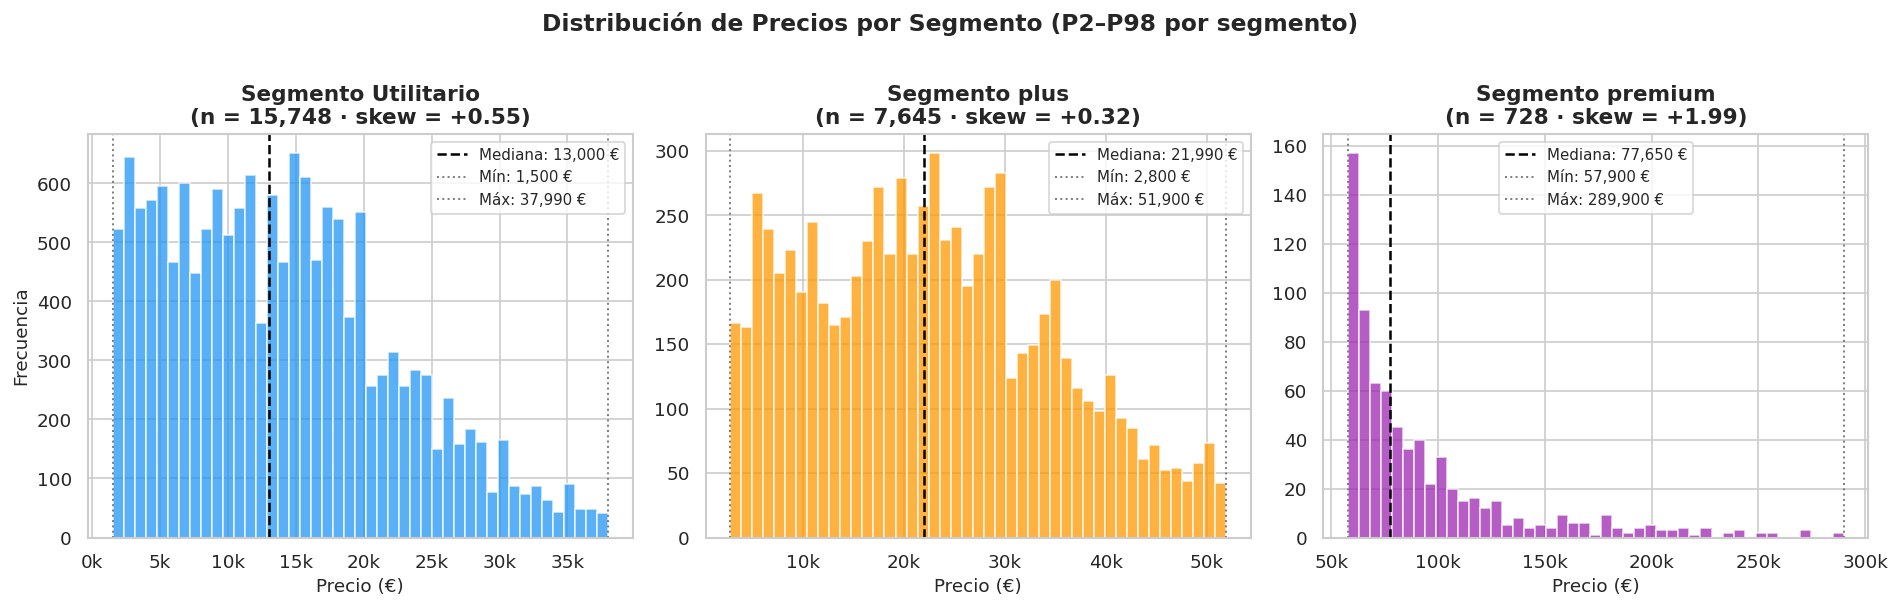

In [25]:
# ── Distribución de precios por segmento ──────────────────────────────────
# Justificación: muestra que cada segmento tiene una distribución propia;
# un análisis global mezclaría tres poblaciones estadísticamente distintas.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, seg in enumerate(SEG_ORDER):
    datos = filtrar_seg(seg)['price']
    med   = datos.median()
    mn    = datos.min()
    mx    = datos.max()
    skew  = datos.skew()
    #print(f'{seg:12s} | mediana={med:>9,.0f} € | media={media:>9,.0f} € | skew={skew:+.2f}')
    col   = SEG_COLORS[seg]

    axes[i].hist(datos, bins=45, color=col, alpha=0.75, edgecolor='white')
    axes[i].axvline(med, color='black', linestyle='--', linewidth=1.5,
                    label=f'Mediana: {med:,.0f} €')
    axes[i].axvline(mn, color='grey', linestyle=':', linewidth=1.2,
                    label=f'Mín: {mn:,.0f} €')
    axes[i].axvline(mx, color='grey', linestyle=':', linewidth=1.2,
                    label=f'Máx: {mx:,.0f} €')

    axes[i].set_title(f'Segmento {seg}\n(n = {len(datos):,} · skew = {skew:+.2f})')
    axes[i].set_xlabel('Precio (€)')
    axes[i].set_ylabel('Frecuencia' if i == 0 else '')
    axes[i].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    axes[i].legend(fontsize=9)

fig.suptitle('Distribución de Precios por Segmento (P2–P98 por segmento)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('IMG/distribucion_precio_segmentos.png', bbox_inches='tight')
plt.show()


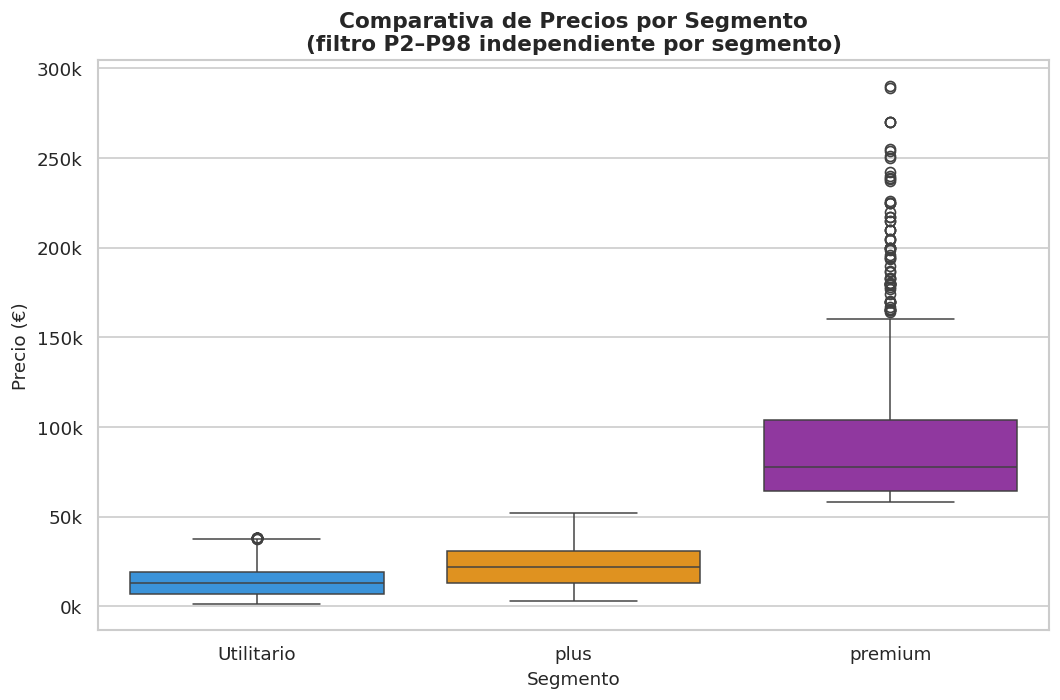

In [9]:
# ── Boxplot comparativo precio × segmento ─────────────────────────────────
# Justificación NUEVA: visualiza la separación entre los tres niveles en un
# único gráfico; es la evidencia visual directa que justifica la segmentación
# adoptada en el TFG frente a una clasificación binaria.
df_plot = pd.concat([filtrar_seg(s) for s in SEG_ORDER])

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(
    data=df_plot, x='segmento', y='price',
    order=SEG_ORDER,
    palette=SEG_COLORS,
    ax=ax,
    linewidth=0.9,
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_title('Comparativa de Precios por Segmento\n(filtro P2–P98 independiente por segmento)')
ax.set_xlabel('Segmento')
ax.set_ylabel('Precio (€)')
plt.tight_layout()
plt.savefig('IMG/boxplot_precio_segmentos.png', bbox_inches='tight')
plt.show()


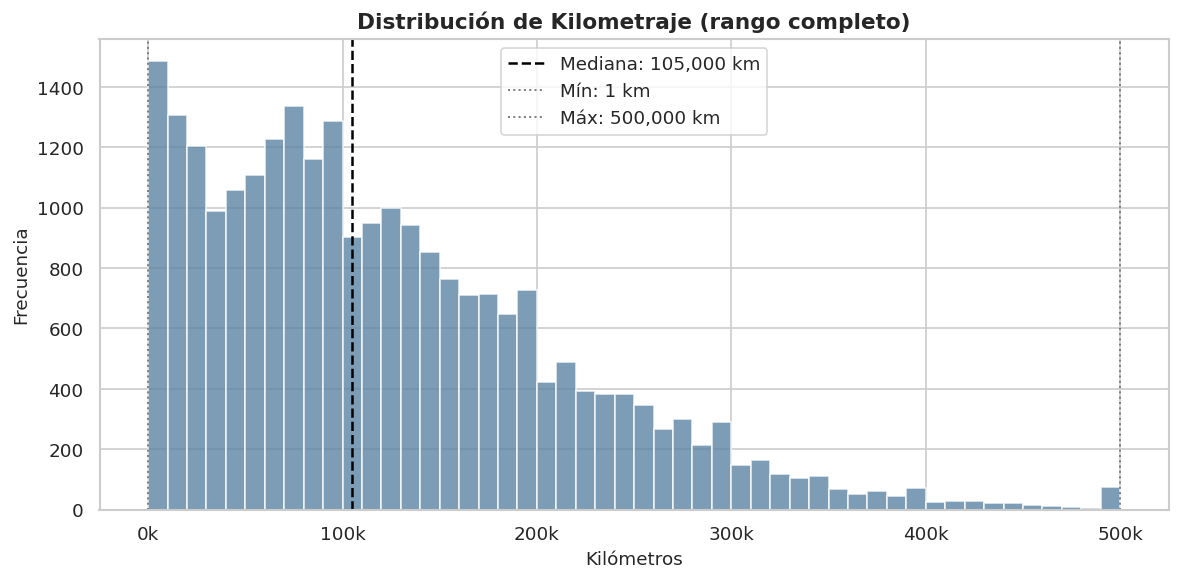

In [26]:
# ── Distribución de kilometraje (rango completo) ──────────────────────────
df_km = df['km'].dropna()
med   = df_km.median()
mn    = df_km.min()
mx    = df_km.max()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_km, bins=50, color='#5C85A4', alpha=0.8, edgecolor='white')
ax.axvline(med, color='black', linestyle='--', linewidth=1.5,
           label=f'Mediana: {med:,.0f} km')
ax.axvline(mn, color='grey', linestyle=':', linewidth=1.2,
           label=f'Mín: {mn:,.0f} km')
ax.axvline(mx, color='grey', linestyle=':', linewidth=1.2,
           label=f'Máx: {mx:,.0f} km')

ax.set_title('Distribución de Kilometraje (rango completo)')
ax.set_xlabel('Kilómetros')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.savefig('IMG/distribucion_km.png', bbox_inches='tight')
plt.show()


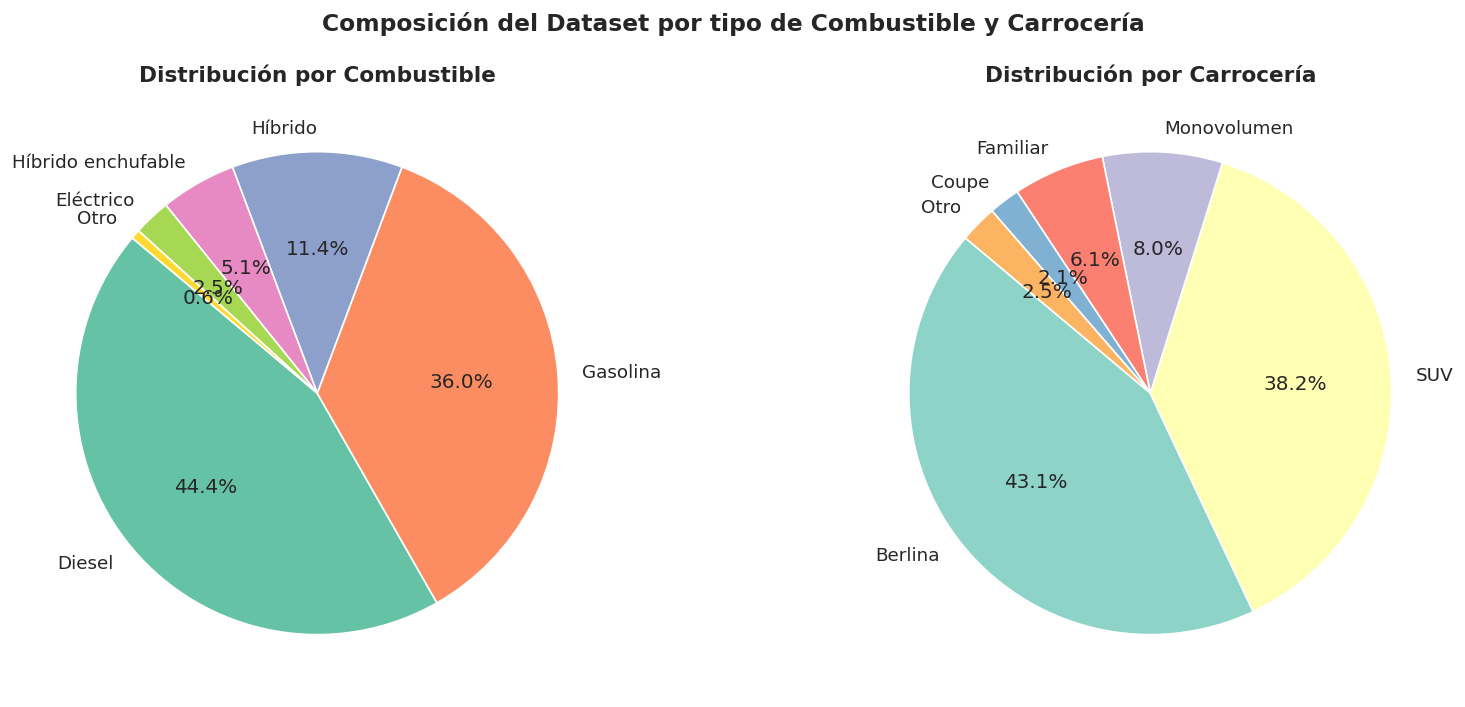

In [27]:
# ── Distribución combustible y carrocería ─────────────────────────────────
# Categorías con < 2% del total se agrupan en 'Otro' para mayor legibilidad.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, titulo in zip(axes,
                            ['fuel',     'car_type'],
                            ['Combustible', 'Carrocería']):
    counts = df[col].value_counts().dropna()
    umbral = counts.sum() * 0.02
    plot   = counts[counts >= umbral].copy()
    resto  = counts[counts < umbral].sum()
    if resto > 0:
        plot['Otro'] = resto
    ax.pie(
        plot,
        labels=plot.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('Set2' if col == 'fuel' else 'Set3', len(plot)),
    )
    ax.set_title(f'Distribución por {titulo}')

fig.suptitle('Composición del Dataset por tipo de Combustible y Carrocería',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('IMG/distribucion_categorias.png', bbox_inches='tight')
plt.show()


## 4. Análisis Bivariante y por Segmento

Las relaciones entre precio y las variables de uso (km, antigüedad) se analizan
**separadas por segmento** para revelar comportamientos que quedarían ocultos en un
análisis global. La antigüedad recibe especial atención por ser la **variable más
importante** en el modelo Random Forest del notebook ML.

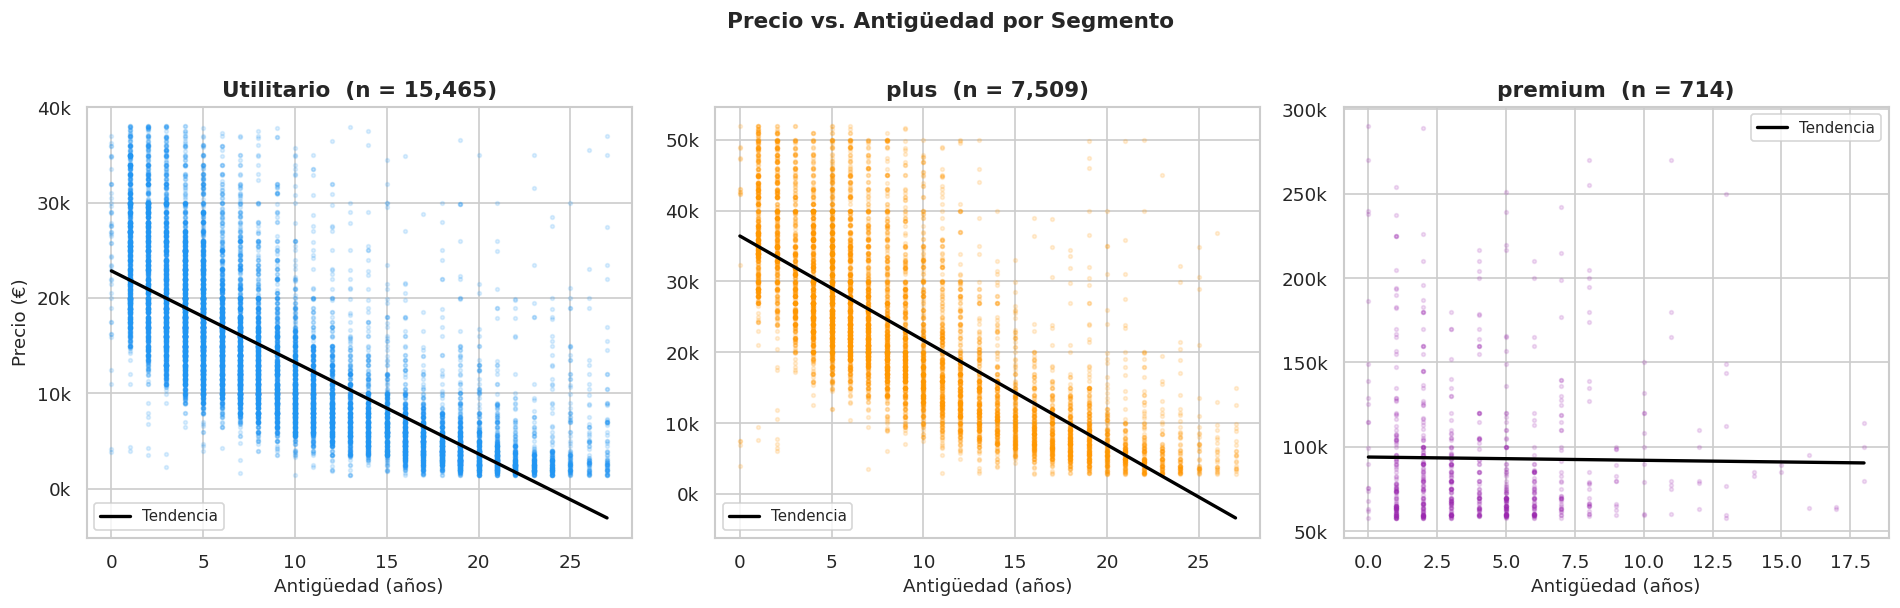

In [28]:
# ── Precio vs. Antigüedad por segmento ────────────────────────────────────
# Justificación NUEVA: 'antiguedad' es la feature con mayor importancia en el
# RandomForestRegressor (ml_coches.ipynb). El EDA debe explorar en detalle esta
# relación y hacerlo por segmento para no mezclar poblaciones heterogéneas.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, seg in enumerate(SEG_ORDER):
    d   = filtrar_seg(seg, col='price').copy()
    d   = d[(d['antiguedad'] >= 0) & (d['antiguedad'] <= d['antiguedad'].quantile(0.98))]
    col = SEG_COLORS[seg]

    axes[i].scatter(d['antiguedad'], d['price'],
                    alpha=0.15, s=5, color=col)

    # Línea de tendencia lineal
    mask = d['antiguedad'].notna() & d['price'].notna()
    z    = np.polyfit(d.loc[mask, 'antiguedad'], d.loc[mask, 'price'], 1)
    x_l  = np.linspace(d['antiguedad'].min(), d['antiguedad'].max(), 100)
    axes[i].plot(x_l, np.poly1d(z)(x_l), color='black',
                 linewidth=2, label='Tendencia')

    axes[i].set_title(f'{seg}  (n = {len(d):,})')
    axes[i].set_xlabel('Antigüedad (años)')
    axes[i].set_ylabel('Precio (€)' if i == 0 else '')
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    axes[i].legend(fontsize=9)

fig.suptitle(
    'Precio vs. Antigüedad por Segmento',
    fontsize=13, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.savefig('IMG/precio_antiguedad_segmentos.png', bbox_inches='tight')
plt.show()


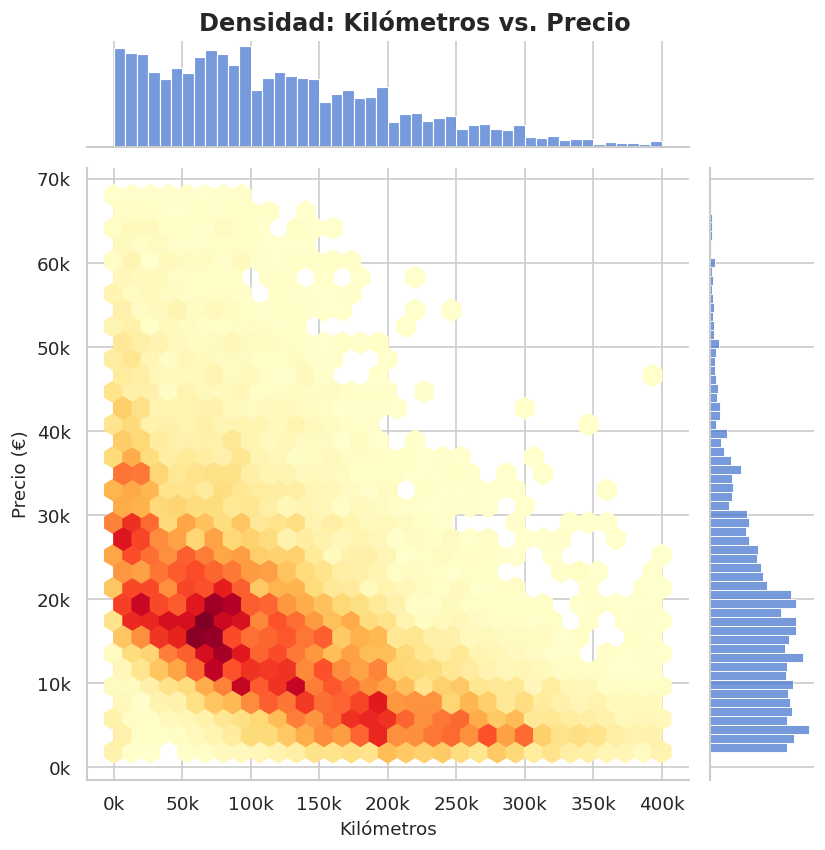

In [13]:
# ── Densidad Kilometraje vs. Precio (hexbin) ──────────────────────────────
df_hex = df[
    p2_p98(df['price']) & df['km'].between(0, 400_000)
].copy()

g = sns.jointplot(
    x='km', y='price', data=df_hex,
    kind='hex', cmap='YlOrRd', gridsize=30, mincnt=1, height=7,
)
g.set_axis_labels('Kilómetros', 'Precio (€)', fontsize=11)
g.ax_joint.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
g.ax_joint.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
g.figure.suptitle('Densidad: Kilómetros vs. Precio', y=1.01, fontweight='bold')
plt.savefig('IMG/km_precio_hexbin.png', bbox_inches='tight')
plt.show()


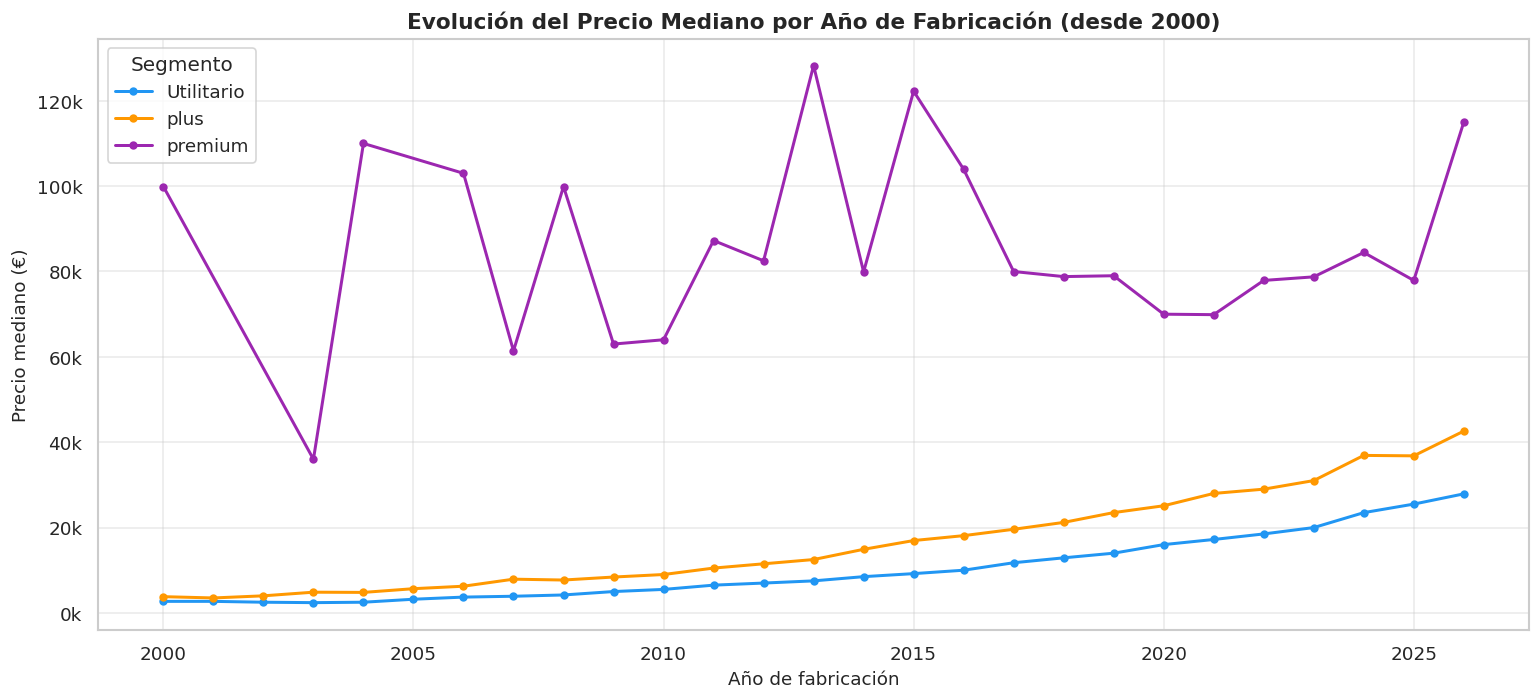

In [14]:
# ── Evolución del precio mediano por año de fabricación ───────────────────
# Adaptación: se muestran las tres curvas por segmento en lugar de una global.
# Revela que la depreciación relativa es más pronunciada en plus/premium.
fig, ax = plt.subplots(figsize=(13, 6))

for seg, col in SEG_COLORS.items():
    med = (
        df[df['segmento'] == seg]
        .groupby('year')['price']
        .median()
        .loc[lambda s: (s.index >= 2000) & (s.index <= ANO_ACTUAL)]
    )
    ax.plot(med.index, med.values,
            marker='o', markersize=4, label=seg, color=col, linewidth=1.8)

ax.set_title('Evolución del Precio Mediano por Año de Fabricación (desde 2000)')
ax.set_xlabel('Año de fabricación')
ax.set_ylabel('Precio mediano (€)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(title='Segmento')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('IMG/evolucion_precio_anio_segmento.png', bbox_inches='tight')
plt.show()


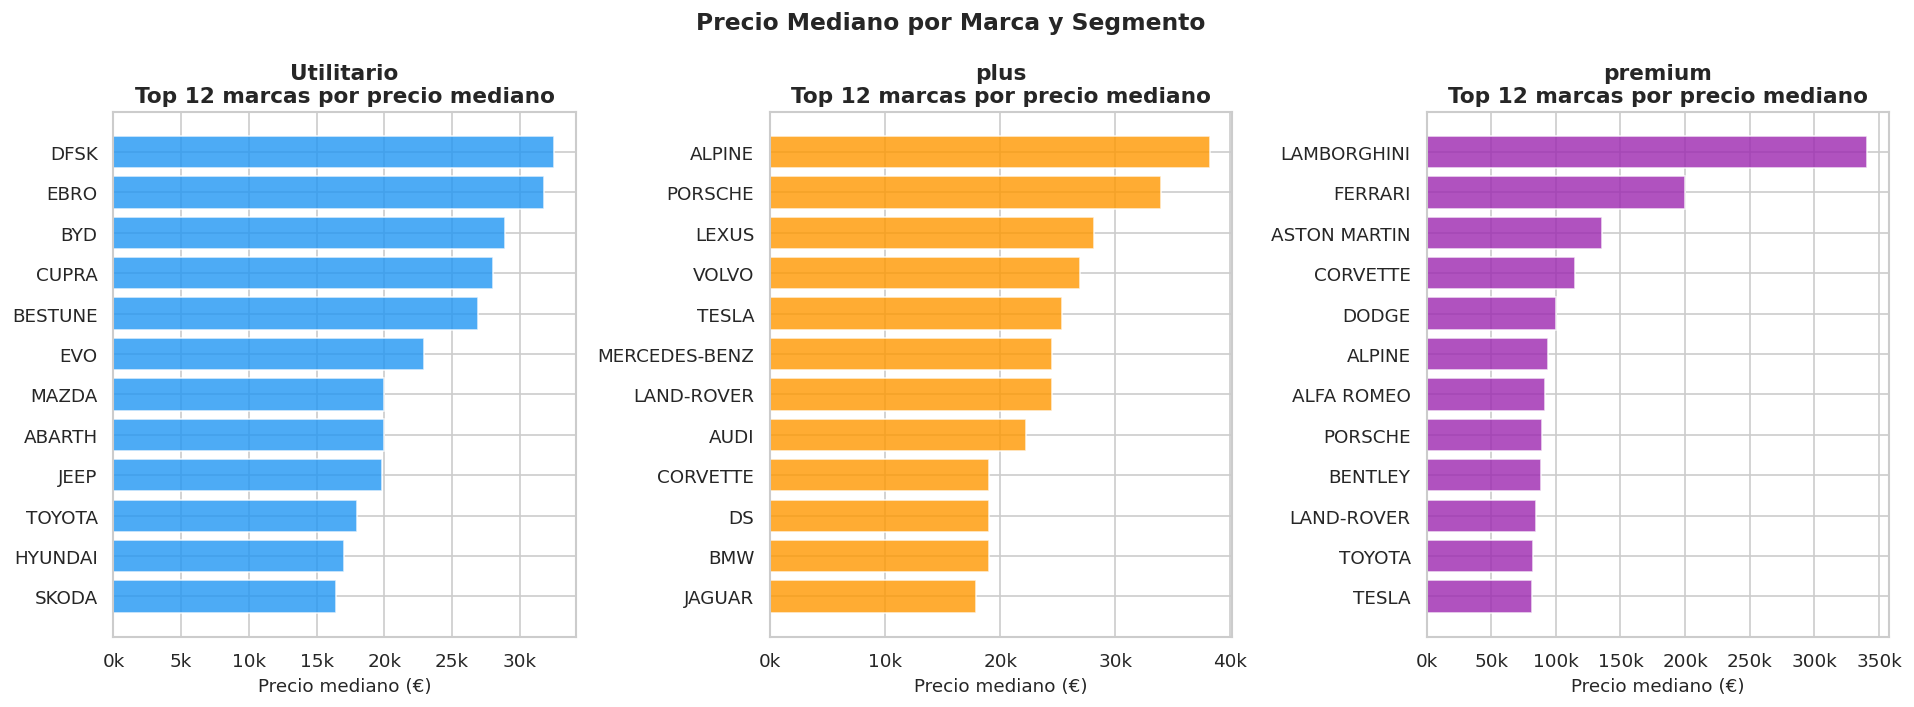

In [15]:
# ── Precio mediano por marca y segmento ───────────────────────────────────
# Justificación NUEVA: en el original había un boxplot con las 10 marcas más
# frecuentes globalmente, sin separación por segmento. Este gráfico muestra
# las top marcas de cada nivel y su precio mediano, facilitando comparaciones
# cruzadas y siendo más legible que un boxplot con muchas cajas.
N_MARCAS = 12
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, seg in enumerate(SEG_ORDER):
    d   = df[df['segmento'] == seg].dropna(subset=['brand'])
    top = (d.groupby('brand')['price']
            .median()
            .nlargest(N_MARCAS)
            .sort_values())        # ascendente → barh de menor a mayor
    col = SEG_COLORS[seg]
    axes[i].barh(top.index, top.values, color=col, alpha=0.8, edgecolor='white')
    axes[i].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    axes[i].set_title(f'{seg}\nTop {N_MARCAS} marcas por precio mediano')
    axes[i].set_xlabel('Precio mediano (€)')

fig.suptitle('Precio Mediano por Marca y Segmento',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('IMG/precio_marca_segmento.png', bbox_inches='tight')
plt.show()


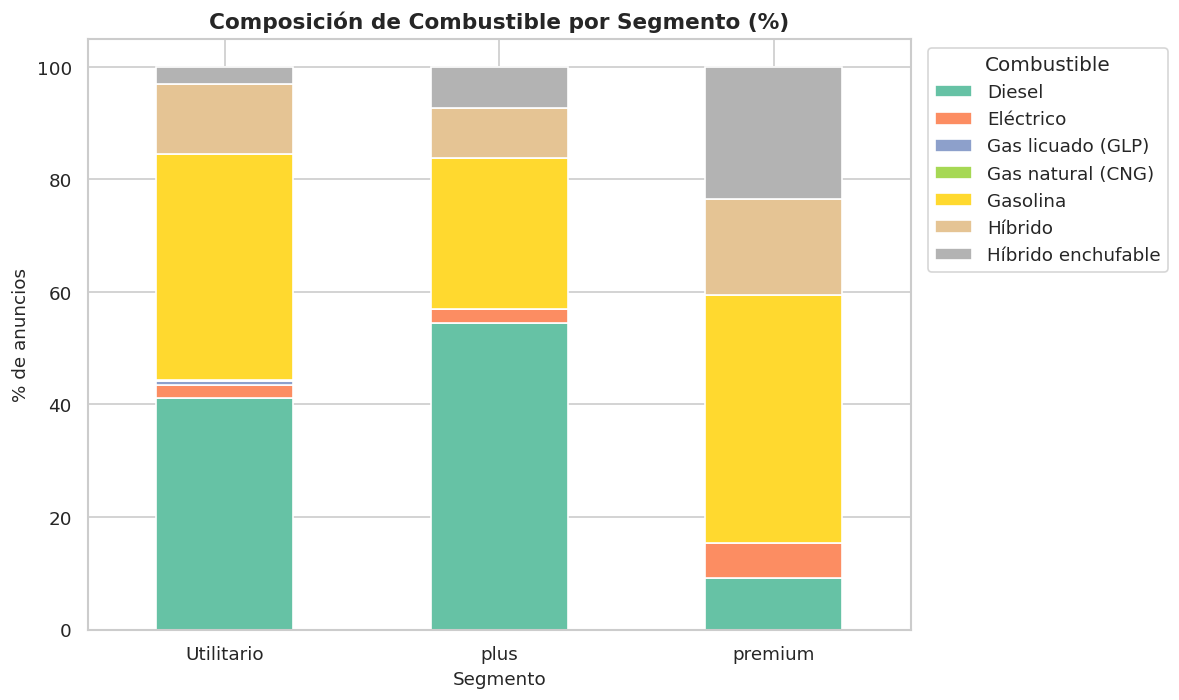

In [16]:
# ── Composición de combustible por segmento ───────────────────────────────
# Justificación NUEVA: muestra que la distribución de combustible difiere
# significativamente entre segmentos (plus/premium tienen mucho mayor
# proporción de híbridos y eléctricos), lo que valida que combustible es una
# feature relevante para la clasificación de segmentos del notebook ML.
fuel_seg = (
    df.dropna(subset=['fuel'])
      .groupby(['segmento', 'fuel'])
      .size()
      .unstack(fill_value=0)
)
# Normalizar a porcentaje
fuel_pct  = fuel_seg.div(fuel_seg.sum(axis=1), axis=0).mul(100)
fuel_pct  = fuel_pct.loc[SEG_ORDER]

fig, ax = plt.subplots(figsize=(10, 6))
fuel_pct.plot(kind='bar', stacked=True, ax=ax,
              colormap='Set2', edgecolor='white', width=0.5)
ax.set_title('Composición de Combustible por Segmento (%)')
ax.set_xlabel('Segmento')
ax.set_ylabel('% de anuncios')
ax.legend(title='Combustible', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(SEG_ORDER, rotation=0)
plt.tight_layout()
plt.savefig('IMG/combustible_por_segmento.png', bbox_inches='tight')
plt.show()


## 5. Análisis Multivariante

Relaciones entre múltiples variables simultáneamente: correlaciones lineales
y distribución de precio en función de combustible y transmisión.

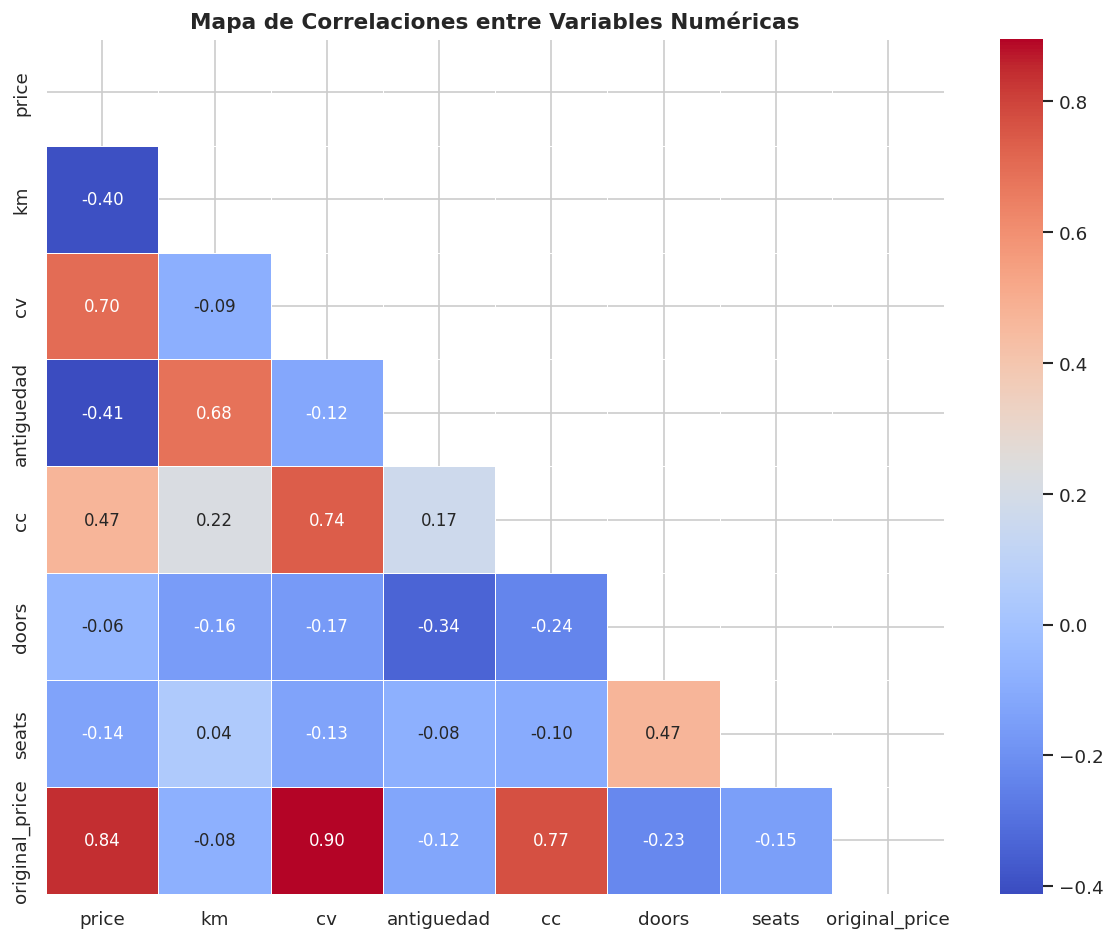

In [17]:
# ── Mapa de correlaciones ─────────────────────────────────────────────────
# Adaptación: se usa 'antiguedad' (variable derivada) en lugar de 'year' y
# 'age' del notebook original, manteniendo coherencia con el pipeline ML.
cols_corr = ['price', 'km', 'cv', 'antiguedad', 'cc', 'doors', 'seats', 'original_price']
cols_disp = [c for c in cols_corr if c in df.columns]
corr      = df[cols_disp].corr()
mask      = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, cmap='coolwarm', fmt='.2f',
    mask=mask, annot_kws={'size': 10},
    linewidths=0.5, ax=ax,
)
ax.set_title('Mapa de Correlaciones entre Variables Numéricas')
plt.tight_layout()
plt.savefig('IMG/mapa_correlaciones.png', bbox_inches='tight')
plt.show()


> **Observación clave:** la correlación más alta con `price` la presenta `cv`
> (potencia), seguida de `cc` (cilindrada) y `antiguedad` (signo negativo: mayor
> antigüedad → menor precio). `km` también correlaciona negativamente, aunque con
> menor intensidad que `antiguedad`, lo que confirma los rankings de importancia
> del modelo Random Forest.

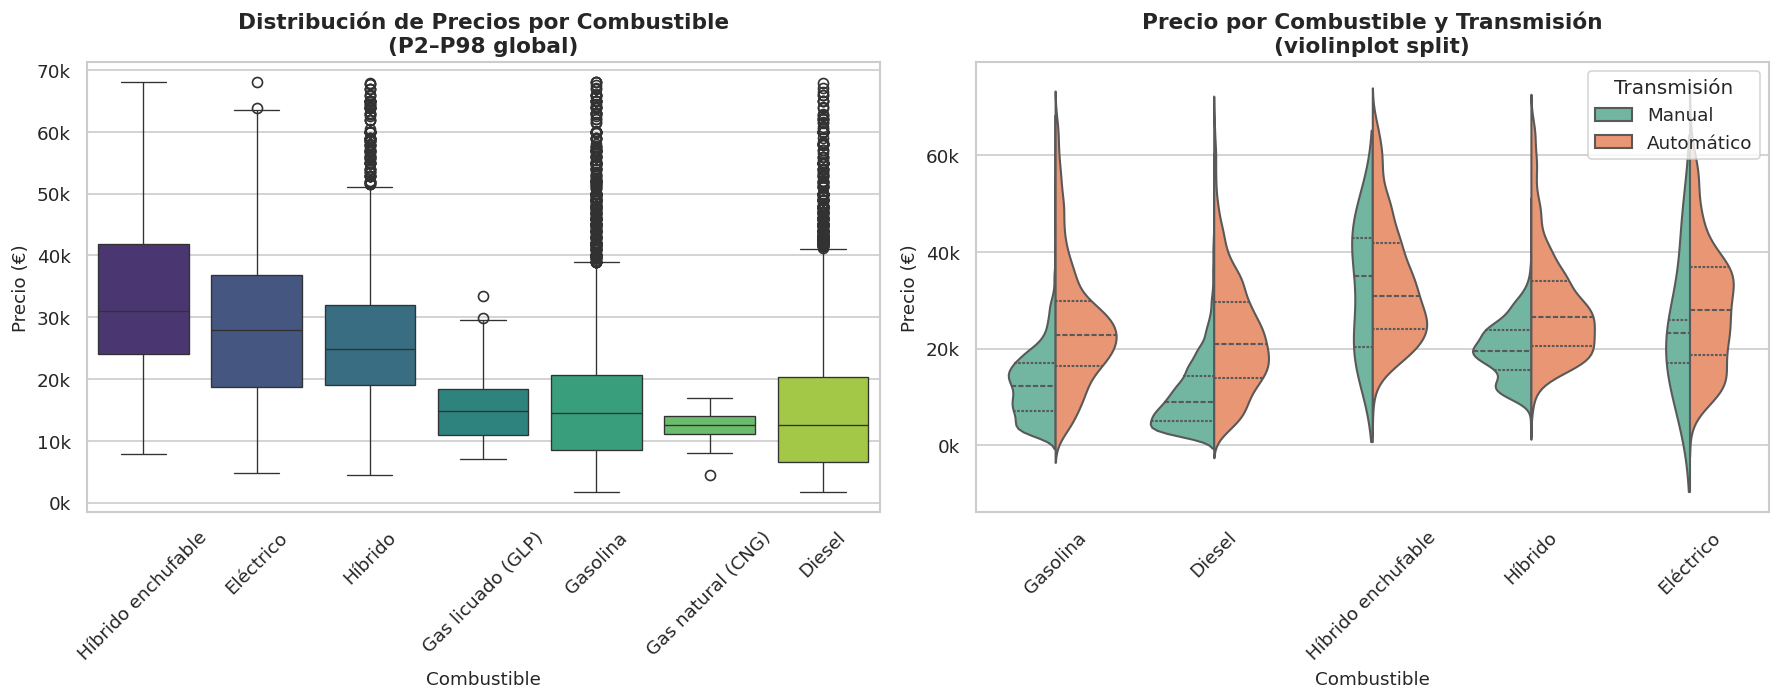

In [18]:
# ── Precio por combustible y transmisión ──────────────────────────────────
df_bi = df[p2_p98(df['price'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

orden_fuel = (df_bi.groupby('fuel')['price']
                   .median()
                   .sort_values(ascending=False)
                   .index)

sns.boxplot(data=df_bi, x='fuel', y='price', order=orden_fuel,
            palette='viridis', ax=axes[0], linewidth=0.8)
axes[0].set_title('Distribución de Precios por Combustible\n(P2–P98 global)')
axes[0].set_xlabel('Combustible')
axes[0].set_ylabel('Precio (€)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

df_vio = df_bi[
    df_bi['transmission'].isin(['Manual', 'Automático']) &
    df_bi['fuel'].isin(['Gasolina', 'Diesel', 'Híbrido enchufable',
                        'Híbrido', 'Eléctrico'])
]
sns.violinplot(
    data=df_vio, x='fuel', y='price',
    hue='transmission', split=True,
    palette='Set2', inner='quart', ax=axes[1],
)
axes[1].set_title('Precio por Combustible y Transmisión\n(violinplot split)')
axes[1].set_xlabel('Combustible')
axes[1].set_ylabel('Precio (€)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Transmisión', loc='upper right')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('IMG/precio_combustible_transmision.png', bbox_inches='tight')
plt.show()


## 6. Distribución Geográfica y Ranking de Marcas

Madrid y Barcelona concentran la mayor parte de la oferta, reflejo de la población
y la densidad de concesionarios. El treemap visualiza el volumen de anuncios por marca,
mientras que la normalización geográfica sigue el umbral de 50 anuncios usado en el
pipeline ML para la variable `location_norm`.

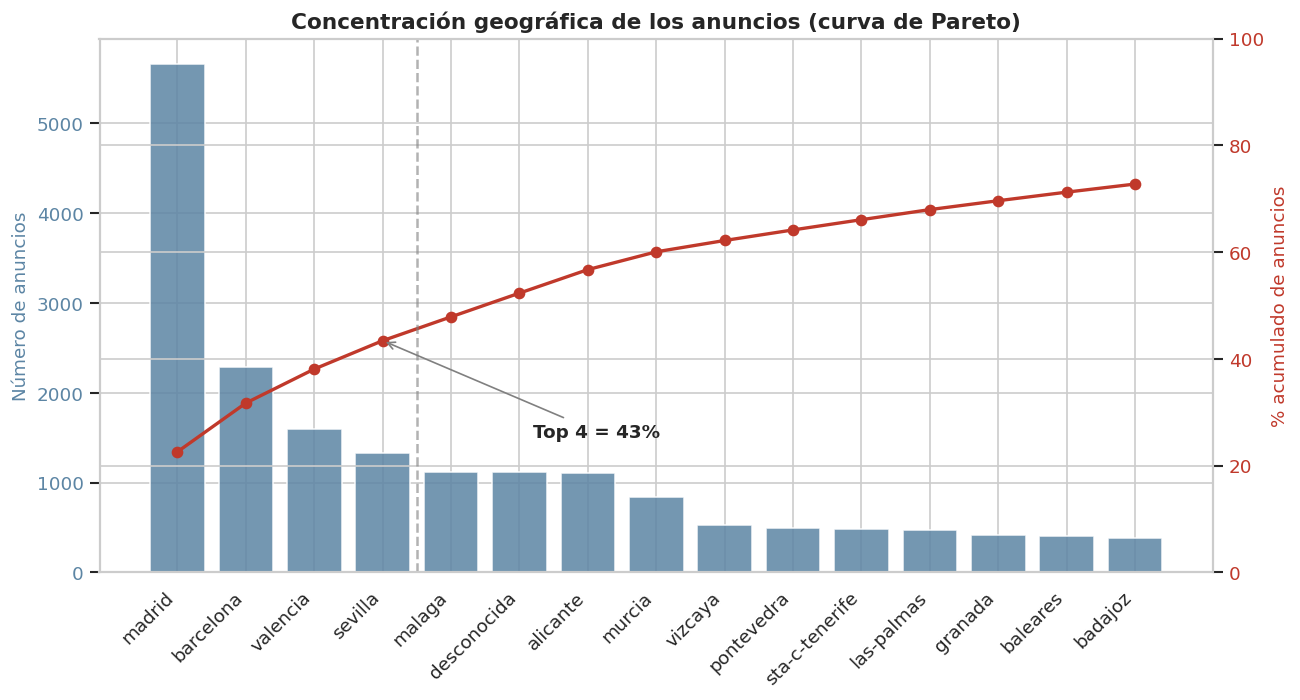

Top 4 provincias:  43.4% de los anuncios
Top 10 provincias: 64.2% de los anuncios


In [19]:
# —— Concentración geográfica (curva de Pareto) ——
# Justificación: el gráfico de barras muestra el volumen, pero NO evidencia la concentración.
# Aquí se añade el % acumulado para demostrar que el top 4 de provincias acapara ~42%
# de los anuncios, sustentando la hipótesis de sesgo hacia mercados urbanos.

loc_counts = df['location'].value_counts().dropna()
top_n = 15
top = loc_counts.head(top_n)

# % acumulado sobre el total de anuncios con provincia
acumulado = top.cumsum() / loc_counts.sum() * 100
pct_top4 = top.head(4).sum() / loc_counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(11, 6))

# Barras: volumen por provincia
ax1.bar(range(len(top)), top.values, color='#5C85A4', alpha=0.85, edgecolor='white')
ax1.set_ylabel('Número de anuncios', color='#5C85A4')
ax1.set_xticks(range(len(top)))
ax1.set_xticklabels(top.index, rotation=45, ha='right')
ax1.tick_params(axis='y', labelcolor='#5C85A4')

# Línea: porcentaje acumulado
ax2 = ax1.twinx()
ax2.plot(range(len(top)), acumulado.values, color='#C0392B', marker='o', linewidth=2)
ax2.set_ylabel('% acumulado de anuncios', color='#C0392B')
ax2.tick_params(axis='y', labelcolor='#C0392B')
ax2.set_ylim(0, 100)

# Marcar el corte del top 4
ax2.axvline(3.5, color='gray', linestyle='--', alpha=0.6)
ax2.annotate(f'Top 4 = {pct_top4:.0f}%',
             xy=(3, acumulado.iloc[3]),
             xytext=(5.2, acumulado.iloc[3] - 18),
             fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='gray'))

ax1.set_title('Concentración geográfica de los anuncios (curva de Pareto)')
plt.tight_layout()
plt.savefig('IMG/concentracion_geografica.png', bbox_inches='tight')
plt.show()

print(f"Top 4 provincias:  {pct_top4:.1f}% de los anuncios")
print(f"Top 10 provincias: {top.head(10).sum() / loc_counts.sum() * 100:.1f}% de los anuncios")


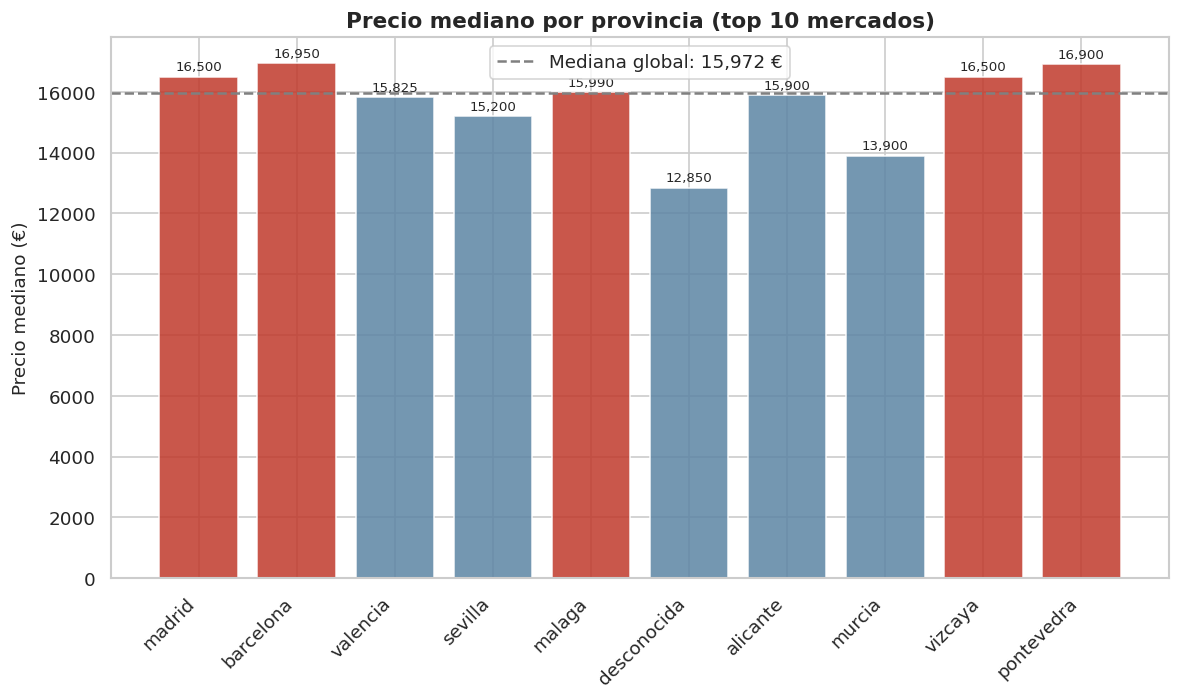

In [20]:
# —— Precio mediano por provincia (top mercados) ——
# Justificación: contrasta la hipótesis del sesgo de precios urbano.
# Se usa la MEDIANA (robusta frente a la fuerte asimetría del precio).
# En rojo, provincias por encima de la mediana global = mercados más caros.

top_provincias = df['location'].value_counts().dropna().head(10).index
sub = df[df['location'].isin(top_provincias)]

precio_mediano = sub.groupby('location')['price'].median().reindex(top_provincias)
mediana_global = df['price'].median()

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#C0392B' if v > mediana_global else '#5C85A4' for v in precio_mediano.values]
ax.bar(range(len(precio_mediano)), precio_mediano.values,
       color=colores, alpha=0.85, edgecolor='white')

ax.axhline(mediana_global, color='gray', linestyle='--', linewidth=1.5,
           label=f'Mediana global: {mediana_global:,.0f} €')

for i, v in enumerate(precio_mediano.values):
    ax.text(i, v + 200, f'{v:,.0f}', ha='center', fontsize=8)

ax.set_title('Precio mediano por provincia (top 10 mercados)')
ax.set_ylabel('Precio mediano (€)')
ax.set_xticks(range(len(precio_mediano)))
ax.set_xticklabels(precio_mediano.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('IMG/precio_mediano_provincia.png', bbox_inches='tight')
plt.show()

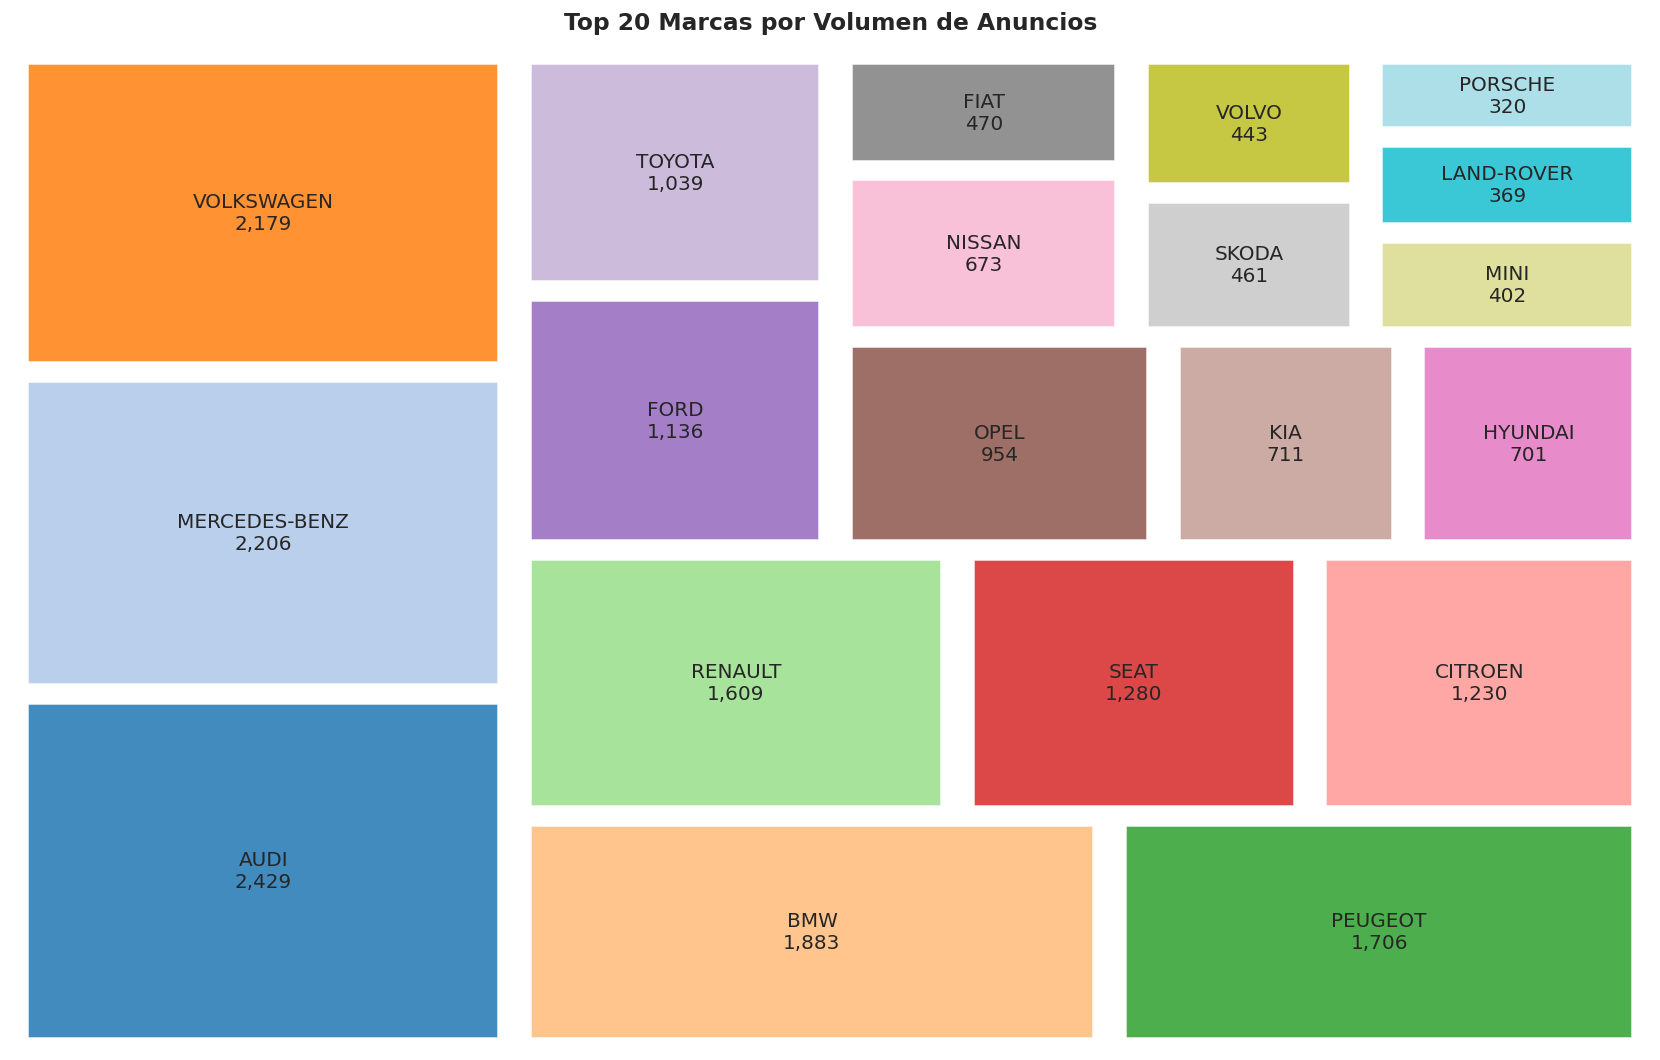

In [21]:
# ── Treemap: volumen de anuncios por marca ────────────────────────────────
brand_counts = df['brand'].value_counts().dropna().head(20)

plt.figure(figsize=(14, 9))
squarify.plot(
    sizes  = brand_counts.values,
    label  = [f"{b}\n{n:,}" for b, n in zip(brand_counts.index, brand_counts.values)],
    alpha  = 0.85,
    pad    = True,
    color  = sns.color_palette('tab20', len(brand_counts)),
)
plt.axis('off')
plt.title('Top 20 Marcas por Volumen de Anuncios',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('IMG/treemap_marcas.png', bbox_inches='tight')
plt.show()


## 7. Análisis de Descuento sobre Precio Original

Solo los anuncios con `original_price` disponible (~65 % del total). El descuento
es la diferencia entre el precio de catálogo nuevo y el precio de segunda mano,
expresado en porcentaje. Revela la **depreciación efectiva** por segmento.

In [22]:
# ── Cálculo de descuento ──────────────────────────────────────────────────
df_orig = df[df['original_price'].notna() & df['price'].notna()].copy()
df_orig['descuento_abs'] = df_orig['original_price'] - df_orig['price']
df_orig['descuento_pct'] = (
    df_orig['descuento_abs'] / df_orig['original_price'] * 100
).round(1)

# Filtrar outliers (P2-P98)
df_orig = df_orig[p2_p98(df_orig['descuento_pct'])].copy()

print(f"Anuncios con precio original disponible: {len(df_orig):,}\n")
print(df_orig.groupby('segmento')['descuento_pct']
             .agg(['mean', 'median', 'std'])
             .round(1)
             .loc[SEG_ORDER]
             .to_string())


Anuncios con precio original disponible: 15,648

            mean  median   std
segmento                      
Utilitario  39.5    37.8  17.5
plus        39.9    38.0  18.1
premium     26.4    25.3  14.8


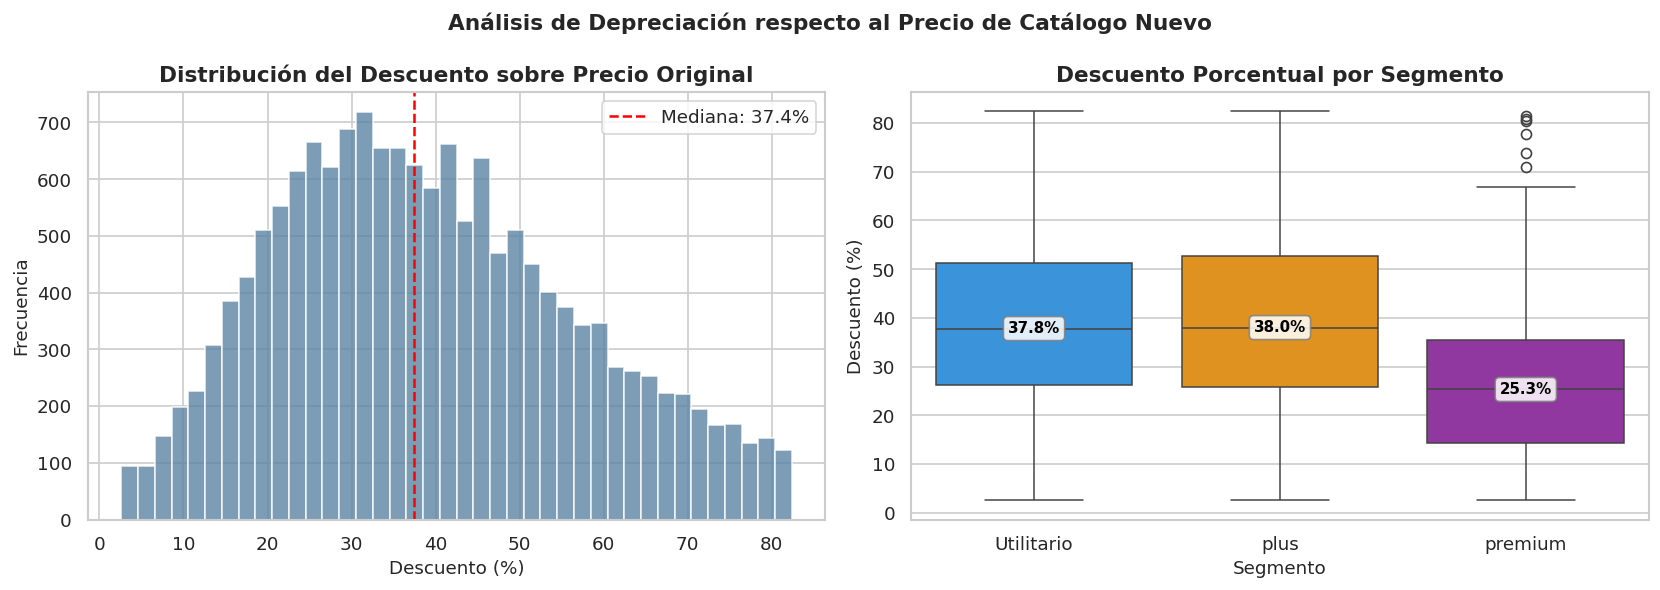

In [29]:
# ── Distribución y comparativa de descuentos ──────────────────────────────
# Justificación NUEVA: muestra que la depreciación porcentual varía por segmento,
# con premium presentando mayor dispersión por la mayor volatilidad de precios
# de colección. Informa el análisis de 'original_price' en el pipeline dbt.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma global
axes[0].hist(df_orig['descuento_pct'], bins=40,
             color='#5C85A4', alpha=0.8, edgecolor='white')
axes[0].axvline(df_orig['descuento_pct'].median(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Mediana: {df_orig['descuento_pct'].median():.1f}%")
axes[0].set_title('Distribución del Descuento sobre Precio Original')
axes[0].set_xlabel('Descuento (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplot por segmento
sns.boxplot(
    data=df_orig, x='segmento', y='descuento_pct',
    order=SEG_ORDER, palette=SEG_COLORS, ax=axes[1], linewidth=0.9,
)

# Mediana por segmento anotada sobre cada caja
medianas_seg = df_orig.groupby('segmento')['descuento_pct'].median()
for i, seg in enumerate(SEG_ORDER):
    med = medianas_seg[seg]
    axes[1].text(i, med, f'{med:.1f}%',
                 ha='center', va='center',
                 fontsize=9, fontweight='bold', color='black',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white',
                           ec='grey', alpha=0.85))

axes[1].set_title('Descuento Porcentual por Segmento')
axes[1].set_xlabel('Segmento')
axes[1].set_ylabel('Descuento (%)')

fig.suptitle('Análisis de Depreciación respecto al Precio de Catálogo Nuevo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('IMG/descuento_precio_original.png', bbox_inches='tight')
plt.show()

In [1]:
# =============================================================================
# CHOROPLETH provincial — volumen y precio MEDIANO
# Canarias reubicadas en un recuadro junto a la península (translate) y
# contador de localizaciones no representadas en el mapa.
# =============================================================================
from matplotlib.patches import Rectangle

# Agrega por provincia (mediana, coherente con el resto del análisis)
agg_prov = (df_geo.dropna(subset=["provincia"])
            .groupby("provincia")
            .agg(n_anuncios=("price", "size"),
                 precio_mediano=("price", "median"))
            .reset_index())
mapa_prov = gdf_prov.merge(agg_prov, left_on="name", right_on="provincia", how="left")

# --- Reubica Canarias junto a la península ---------------------------------
# Se identifican por NOMBRE (el cod_ccaa de este GeoJSON no sigue la numeración INE)
CANARIAS = ["Las Palmas", "Santa Cruz De Tenerife"]
XOFF, YOFF = 8.5, 6.3  # desplazamiento en grados (lon, lat) hacia el SO peninsular
_es_can = mapa_prov["name"].isin(CANARIAS)
mapa_prov.loc[_es_can, "geometry"] = mapa_prov.loc[_es_can, "geometry"].translate(
    xoff=XOFF, yoff=YOFF)
_box = mapa_prov.loc[_es_can].total_bounds  # bounds ya trasladados, para el recuadro

# --- Contador de localizaciones desconocidas -------------------------------
# Nulas (location vacía) + slugs que no emparejan con ninguna provincia
_n_null   = int(df_geo["location"].isna().sum())
_no_match = df_geo.loc[df_geo["location"].notna() & df_geo["provincia"].isna(),
                       "location"].value_counts()
_n_desc   = _n_null + int(_no_match.sum())
print(f"Localizaciones desconocidas: {_n_desc} "
      f"(nulas: {_n_null}, sin emparejar: {int(_no_match.sum())})")
if len(_no_match):
    print(_no_match.to_string())  # si aparece algún slug real, añádelo al ALIAS

# --- Función reutilizable de coropleta --------------------------------------
def dibujar_coropleta(gdf, columna, titulo, cmap, fichero, fmt_euro=False,
                      box=None, n_desconocidas=0):
    fig, ax = plt.subplots(figsize=(11, 9))
    gdf.plot(column=columna, ax=ax, cmap=cmap, edgecolor="white", linewidth=0.4,
             legend=True, legend_kwds={"shrink": 0.6, "label": titulo},
             missing_kwds={"color": "#ededed", "edgecolor": "white",
                           "linewidth": 0.4, "label": "Sin datos"})
    if fmt_euro:  # formatea la leyenda en euros
        cb = ax.get_figure().axes[-1]
        cb.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €"))
    if box is not None:  # recuadro punteado alrededor de Canarias
        m = 0.25
        ax.add_patch(Rectangle((box[0] - m, box[1] - m),
                               (box[2] - box[0]) + 2 * m, (box[3] - box[1]) + 2 * m,
                               fill=False, edgecolor="#555", linewidth=0.8, linestyle="--"))
        ax.text(box[0] - m, box[3] + m + 0.1, "Canarias", fontsize=8, color="#555")
    if n_desconocidas:  # nota con los anuncios no representados
        ax.text(0.01, 0.01, f"Localizaciones desconocidas: {n_desconocidas:,}",
                transform=ax.transAxes, fontsize=9, color="#444", ha="left", va="bottom")
    ax.set_title(titulo, fontsize=14, pad=12)
    ax.axis("off")
    plt.savefig(f"IMG/{fichero}", bbox_inches="tight", dpi=150)
    plt.show()

Path("IMG").mkdir(exist_ok=True)

# Mapa 1: volumen de anuncios
dibujar_coropleta(mapa_prov, "n_anuncios",
                  "Distribución de anuncios por provincia",
                  "YlOrRd", "mapa_volumen_provincia.png",
                  box=_box, n_desconocidas=_n_desc)

# Mapa 2: precio mediano
dibujar_coropleta(mapa_prov, "precio_mediano",
                  "Precio mediano por provincia (€)",
                  "viridis", "mapa_precio_provincia.png", fmt_euro=True,
                  box=_box, n_desconocidas=_n_desc)

NameError: name 'df_geo' is not defined